# Lecture 3 - (05/02/2026)

### Today's Topics:

- Lambda functions
- Data Representation and Pandas
- Loss Functions

## Lambda functions
- Lambda expressions are “small anonymous functions”
- Mainly used for small and temporary tasks.
- Very common for `apply()` (and `map()` & `reduce()`).
- They can be stored as a variable and used as a function

In [3]:
f = lambda x : x**2
f(4), f(6), f(8), f(10)

(16, 36, 64, 100)

In [27]:
pairs = [('Alice', 94), ('Bob', 87), ('Charlie', 78), ('David', 88), ('Emily', 83)]
pairs.sort(key = lambda pair : pair[1])
pairs

[('Charlie', 78), ('Emily', 83), ('Bob', 87), ('David', 88), ('Alice', 94)]

Example: create a new column that is true a pokemon has two types

In [13]:
import pandas as pd
df = pd.read_csv("https://gist.githubusercontent.com/armgilles/194bcff35001e7eb53a2a8b441e8b2c6/raw/92200bc0a673d5ce2110aaad4544ed6c4010f687/pokemon.csv")
df.head()

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False


In [16]:
df = df.assign(two_type_boolean = lambda row : (row["Type 2"].notna()))
df.head()

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary,two_type_boolean
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False,True
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False,True
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False,True
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False,True
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False,False


## Pandas

![image](../attachments/pandas_logo.png)

- We will use the popular Python Data Analysis Library (Pandas).
- Open source and freely available, in collab & most distributions.
- Pandas documentation: [Getting Started](https://pandas.pydata.org/docs/getting_started/index.html)

Reading and Writing to CSV's

![image](../attachments/pandas_file_io.png)

In [ ]:
import pandas as pd
df = pd.read_csv('infile.csv')
pass
pass
pass
df.to_csv('outfile.csv', index=False)

Constructing from a dictionary:

![image](../attachments/pandas_df_from_dict.png)

### Selecting by label

![image](../attachments/babyDFwLabels.png)

In [94]:
baby = pd.read_csv("https://raw.githubusercontent.com/jsvine/babynames/refs/heads/master/data/name-counts.csv")
baby.head()

,year,name,sex,count
0,1880,Mary,F,7065
1,1880,Anna,F,2604
2,1880,Emma,F,2003
3,1880,Elizabeth,F,1939
4,1880,Minnie,F,1746


In [28]:
#  The first arguement is the row label
#       \/ 
baby.loc[1, 'name']
#            /\
#       The second arguement is the column label

'Anna'

Selects the entry in row 1, column "name" which is 'Anna'

We can also select a range of values

In [29]:
baby.loc[1:3, 'name':'count'] # is inclusive!

,name,sex,count
1,Anna,F,2604
2,Emma,F,2003
3,Elizabeth,F,1939


In [26]:
# Just extract the name and count columns
baby.loc[:, ['name', 'count']]
#            list of column labels

,name,count
0,Mary,7065
1,Anna,2604
2,Emma,2003
3,Elizabeth,1939
4,Minnie,1746
...,...,...
1758725,Zylin,5
1758726,Zymari,5
1758727,Zyrin,5
1758728,Zyrus,5


What happens if you use single versus double brackets?

In [31]:
# Shorthand for baby.loc[:, 'name']
type(baby['name']), baby['name']

(pandas.Series,
 0               Mary
 1               Anna
 2               Emma
 3          Elizabeth
 4             Minnie
              ...    
 1758725        Zylin
 1758726       Zymari
 1758727        Zyrin
 1758728        Zyrus
 1758729    Zytaevius
 Name: name, Length: 1758730, dtype: str)

Returns a series (pandas equivalent to a list/vector) and not a entire dataframe

### Boolean Selection

- We can build more complex selections using Boolean selection
- Create a Series of Booleans that selects rows where the Series is True:

In [36]:
baby.loc[baby['year'] == 2000, :]
# baby.loc[baby['year'] == 2000] also works here

,year,name,sex,count
1332388,2000,Emily,F,25953
1332389,2000,Hannah,F,23069
1332390,2000,Madison,F,19967
1332391,2000,Ashley,F,17994
1332392,2000,Sarah,F,17681
...,...,...,...,...
1362146,2000,Zeph,M,5
1362147,2000,Zeven,M,5
1362148,2000,Ziggy,M,5
1362149,2000,Zo,M,5


In [41]:
baby.loc[baby['count'] == 5]

,year,name,sex,count
835,1880,Adelle,F,5
836,1880,Adina,F,5
837,1880,Adrienne,F,5
838,1880,Albertine,F,5
839,1880,Alys,F,5
...,...,...,...,...
1758725,2012,Zylin,M,5
1758726,2012,Zymari,M,5
1758727,2012,Zyrin,M,5
1758728,2012,Zyrus,M,5


### Modeling and Estimation

Essentially, all models are wrong, but some are useful. - George Box, Statistician (1919-2013)

- A model is an idealized representation of a system.
- Example: weather forecasts make predictions that are often (in)correct
but sometimes not.

In [42]:
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv"
tips = pd.read_csv(url)

Code for histogram:

<Axes: xlabel='tip', ylabel='Count'>

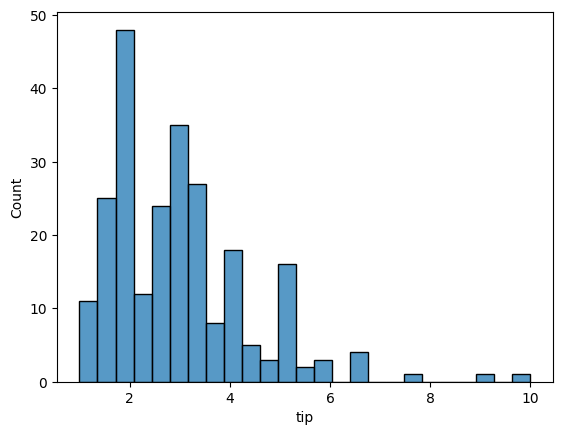

In [49]:
# for class
import seaborn as sns
sns.histplot(tips['tip'], bins=25)

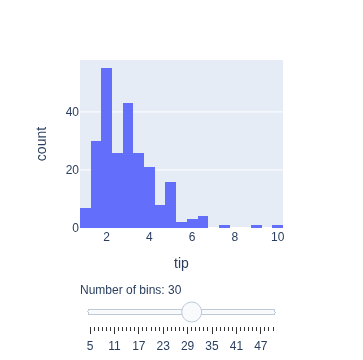

In [72]:
# more advanced visualization
# variable binning

import plotly.express as px

fig = px.histogram(tips, x="tip")
fig.update_layout(
    sliders=[{
        "active": 25,
        "currentvalue": {"prefix": "Number of bins: "},
        "pad": {"t": 50},
        "steps": [
            {
                "label": str(b),
                "method": "restyle",
                "args": [{"nbinsx": b}]
            }
            for b in range(5, 51)
        ]
    }]
)
fig.show()


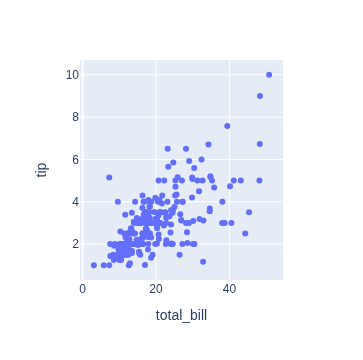

In [64]:
px.scatter(tips, x='total_bill', y='tip')

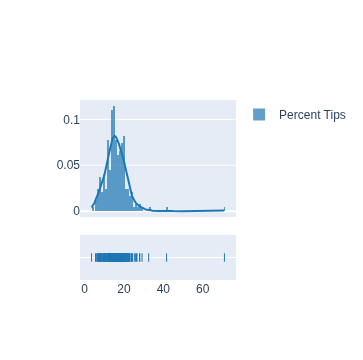

In [79]:
import plotly.figure_factory as ff

tips['percent'] = tips['tip'] / tips['total_bill'] * 100
fig = ff.create_distplot([tips['percent']], ["Percent Tips"])
fig.show()

What would be a good estimate, $\theta$, for percent tip?

Plotly related reading: 

- [Histograms](https://plotly.com/python/histograms/)
- [Distribution Plot](https://plotly.com/python/distplot/)

## Loss Functions

- To quantify how good an estimate is, we will use loss functions.
- A loss function:
    - takes in an estimate $\theta$ and the points in our dataset, $y_1, y_2, ..., y_n$, and
    - outputs a single number, the loss, that measures how well $\theta$ fits the data
- The choice of loss function affects the downstream analysis.

Let's try something simple: taking the minimum difference, that is

$$ f(\theta, y_1, y_2, \cdots, y_n) = \min(y_1 - \theta, y_2 - \theta, \cdots, y_n - \theta)$$

Suppose $\theta = 15$, then:

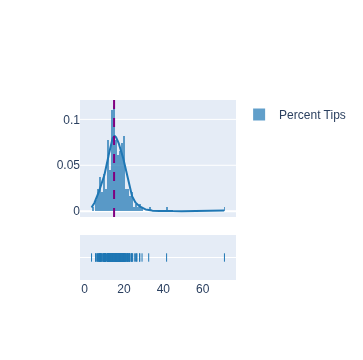

In [84]:
tips['percent'] = tips['tip'] / tips['total_bill'] * 100
fig = ff.create_distplot([tips['percent']], ["Percent Tips"])
fig.add_vline(x=15, line_color = 'purple', line_dash = 'dash')
fig.show()

For tips, this would be for $\theta = 15$:

$$ = \min(−9.055327, 1.054159, 1.658734, \cdots , 0.974441)$$

$$ = −11.436186414864453$$

Doesn't capture much information about the values... just the smallest one

Let’s sum up the differences instead:

$$ f(\theta, y_1, y_2, \cdots, y_n) = (y_1 - \theta) + (y_2 - \theta) + \cdots + (y_n - \theta)$$

For tips, this would be $\theta = 15$:

$$ = −9.055327 + 1.054159 + 1.658734 + \cdots + 0.974441$$
$$ = 263.58299402911507$$

With the negative values, the differences are cancelling out.

To avoid the differences cancelling, make the differences positive:
- Use absolute value of the differences:
$$ f(\theta, y_1, y_2, \cdots, y_n) = |y_1 - \theta| + |y_2 - \theta| + \cdots + |y_n - \theta|$$
- Square the differences:
$$ f(\theta, y_1, y_2, \cdots, y_n) = (y_1 - \theta)^2 + (y_2 - \theta)^2 + \cdots + (y_n - \theta)^2$$

Now we're getting somewhere! We should normalize the number so we can compare it between different sample sizes.

- Mean Absolute Error: Use average of absolute value of the differences:

$$ f(\theta, y_1, y_2, \cdots, y_n) = \frac{1}{n}(|y_1 - \theta| + |y_2 - \theta| + \cdots + |y_n - \theta|)$$

- Mean Squared Error: Use average of the square the differences:

$$ f(\theta, y_1, y_2, \cdots, y_n) = \frac{1}{n}((y_1 - \theta)^2 + (y_2 - \theta)^2 + \cdots + (y_n - \theta)^2)$$

Later we will learn loss functions for more complex models

### Applying functions to Series

- Pandas has a mechanism for applying a function to every element in a
Series, called `apply`

- Similar to aggregate functions, but slower and works on a single
column of data.

In [85]:
names = baby['name']
names.apply(len)

0          4
1          4
2          4
3          9
4          6
          ..
1758725    5
1758726    6
1758727    5
1758728    5
1758729    9
Name: name, Length: 1758730, dtype: int64

We can use built in functions... or we can write our own:

In [86]:
first_letter = lambda x : x[0]

names.apply(first_letter)

0          M
1          A
2          E
3          E
4          M
          ..
1758725    Z
1758726    Z
1758727    Z
1758728    Z
1758729    Z
Name: name, Length: 1758730, dtype: str

Since apply returns a series, we can use it to create a new column in our dataframe.

In [96]:
baby['firsts'] = names.apply(first_letter)
baby.head()

,year,name,sex,count,firsts
0,1880,Mary,F,7065,M
1,1880,Anna,F,2604,A
2,1880,Emma,F,2003,E
3,1880,Elizabeth,F,1939,E
4,1880,Minnie,F,1746,M


alternatively:

In [98]:
baby = baby.assign(firsts=names.apply(first_letter))
baby.head()

,year,name,sex,count,firsts
0,1880,Mary,F,7065,M
1,1880,Anna,F,2604,A
2,1880,Emma,F,2003,E
3,1880,Elizabeth,F,1939,E
4,1880,Minnie,F,1746,M


Last thing, let's step by step take the MSE for our `tips` dataframe

This will be our pipeline:

1. Calculate the `difference` between each item and 15
2. Calculate the `squared` value of each of the values in `difference`
3. Sum the `squared` row
4. Divide by the number of rows we have

In [101]:
n = 15
difference_fn = lambda x : x-15

tips = tips.assign(difference=tips['percent'].apply(difference_fn))
tips.head()

,total_bill,tip,sex,smoker,day,time,size,percent,difference
0,16.99,1.01,Female,No,Sun,Dinner,2,5.944673,-9.055327
1,10.34,1.66,Male,No,Sun,Dinner,3,16.054159,1.054159
2,21.01,3.50,Male,No,Sun,Dinner,3,16.658734,1.658734
3,23.68,3.31,Male,No,Sun,Dinner,2,13.978041,-1.021959
4,24.59,3.61,Female,No,Sun,Dinner,4,14.680765,-0.319235


In [103]:
squared_fn = lambda x : x**2

tips = tips.assign(squared=tips['difference'].apply(squared_fn))
tips.head()

,total_bill,tip,sex,smoker,day,time,size,percent,difference,squared
0,16.99,1.01,Female,No,Sun,Dinner,2,5.944673,-9.055327,81.998941
1,10.34,1.66,Male,No,Sun,Dinner,3,16.054159,1.054159,1.111250
2,21.01,3.50,Male,No,Sun,Dinner,3,16.658734,1.658734,2.751398
3,23.68,3.31,Male,No,Sun,Dinner,2,13.978041,-1.021959,1.044401
4,24.59,3.61,Female,No,Sun,Dinner,4,14.680765,-0.319235,0.101911


In [110]:
tips['squared'].sum() / tips['squared'].count()

np.float64(38.31223773226083)

Let's combine this into one function:

In [125]:
def calculate_loss(df, theta, func = lambda x : x**2):
    difference_fn = lambda x : x-theta
    
    df = df.assign(difference=df['percent'].apply(difference_fn))
    df = df.assign(new=df['difference'].apply(func))
    return df['new'].sum() / df['new'].count()

In [140]:
calculate_loss(tips, 10)

np.float64(74.11481945476554)

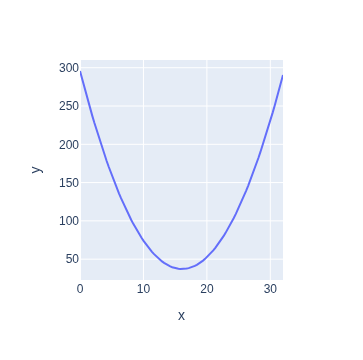

In [137]:
import numpy as np

thetas = np.linspace(0, 32, 100)
losses = [calculate_loss(tips, theta) for theta in thetas]

px.line(x=thetas,y=losses)

In [142]:
min_idx = np.argmin(losses)
print(f'Minimum Theta: {thetas[min_idx]}')
print(f'Minimum MSE: {losses[min_idx]}')

Minimum Theta: 16.161616161616163
Minimum MSE: 37.15189913598053
